In [1]:
# SSAV

# import libraries
import ssav_helpers
from ssav_helpers import *
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from dataclasses import dataclass

In [2]:
L = np.array([2*np.pi, 2*np.pi])
N = np.array([128, 128])

@dataclass
class Parameters:
    eps: float
    M: float
    m: float
    S: float
    B: float

@dataclass
class TimeDomain:
    #dt_min: float
    #dt_max: float
    dt: float
    t0: float
    tf: float

Grid = generate_Grid(L, N, dim=2)
D = -1j*Grid.k
G = -Grid.k2

Time = TimeDomain(dt=0.01, t0=0, tf=2)

Para = Parameters(eps=0.1, M=1.0, m=0.0, S=1.0, B=2.0)

Nt = int(Time.tf / Time.dt)


In [3]:
u = 0.05 * np.sin(Grid.xx) * np.sin(Grid.yy)
ufft = fft2(u)

F, f = compute_F(u)
int_F = np.sum(F) * np.prod(Grid.d)

w_old = compute_w(int_F, Para.B)

E = []
E.append(compute_E(ufft, w_old, Grid, Para))

H = compute_H(f, w_old)

r = -0.5 * np.sum(H*u)*np.prod(Grid.d) + w_old
H2 = fft2(H)

r_tilde = u/Time.dt - Para.S*np.real(ifft2(G*ufft)) - r*np.real(G*H2)

r_hat = r_tilde

P1 = Para.eps**2*G*D**2 - Para.S*G

P = 1/Time.dt + P1

r_hat = fft2(r_hat)
psi_r = r_hat / P
psi_r = np.real(ifft2(psi_r))

psi_H = (G * H2) / P
psi_H = np.real(ifft2(psi_H))

innprod_Hu = compute_ip(H, psi_r, psi_H, Grid)

w = 0.5*innprod_Hu + r

u_old = u
uold_fft = ufft

u = 0.5*innprod_Hu * psi_H * psi_r
ufft = fft2(u)

E.append(compute_E(ufft, w, Grid, Para))

In [4]:
print(E)

[np.float64(9.959676070044988), np.float64(9.857281600370163)]


In [5]:
print(Nt)

200


In [6]:
t = Time.dt

for i in range(Nt):

    u_new, w_new = compute_unew(u, ufft, u_old, uold_fft, w, w_old, Time.dt, Para, Grid, G, P1, t)

    unew_fft = fft2(u_new)

    E.append(compute_E(unew_fft, w_new, Grid, Para))

    w_old = w
    w = w_new

    u_old = u
    u = u_new

    uold_fft = ufft
    ufft = unew_fft

    t += Time.dt

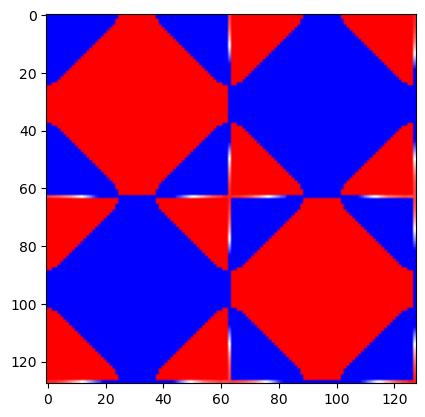

In [8]:
img = plt.imshow(u, cmap = 'bwr')
img.set_clim(-1,1)

plt.colorbar
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

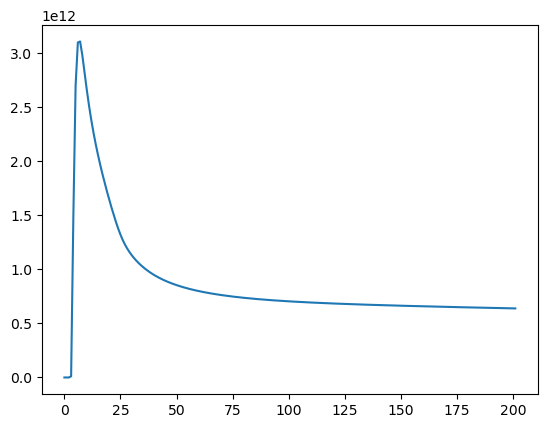

In [9]:
plt.plot(E)
plt.show

In [10]:
print(E)

[np.float64(9.959676070044988), np.float64(9.857281600370163), np.float64(270349.06165718177), np.float64(10916565603.180824), np.float64(1496229993101.448), np.float64(2702952355896.736), np.float64(3100252426347.275), np.float64(3109663942094.995), np.float64(2981750060142.9663), np.float64(2819469376248.1167), np.float64(2659539274515.588), np.float64(2512947033786.8984), np.float64(2381251575420.864), np.float64(2262910100982.081), np.float64(2155615038893.0327), np.float64(2057143853074.665), np.float64(1965635595471.4897), np.float64(1879625713883.4844), np.float64(1798002319217.4111), np.float64(1719951537809.9202), np.float64(1644943439589.7866), np.float64(1572764570548.8506), np.float64(1503571684163.809), np.float64(1437941383240.8467), np.float64(1376851234830.3496), np.float64(1321441537691.3367), np.float64(1272516632409.4087), np.float64(1230058433978.3364), np.float64(1193245616660.6077), np.float64(1160949946414.737), np.float64(1132182922026.013), np.float64(110623329